NAME: AISHWARYA GADELA (1CD24EC007)

COLLEGE: CAMBRIDGE INSTITUTE OF TECHNOLOGY

BRANCH: ELECTRONICS AND COMMUNICATION ENGINEERING

PROBLEM STATEMENT: SOLAR POWER GENERATIONESTIMATTION FROM IRRADIANCE, PANEL ANGLE, AND TEMPERATURE.

In [44]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [45]:
df = pd.read_csv("/solar_power.csv")

In [46]:
df.head()

,irradiance_wm2,panel_angle_degrees,temperature_c,panel_type,panel_efficiency_percent,array_size_kw,shading_percent,dust_coverage,inverter_efficiency,tracking_system,climate_zone,maintenance_status,power_output_kw
0,854.942691,34.939874,12.136416,Monocrystalline,19.908985,73.252112,4.452474,Clean,96.266765,Dual-Axis,Polar,Good,29.220686
1,873.514217,58.963949,40.301998,Polycrystalline,21.918331,21.524243,3.320695,Moderate,95.735455,Fixed,Arid,Fair,58.413629
2,291.329020,19.630756,6.456214,Polycrystalline,16.079822,30.092401,18.615808,Clean,94.368534,Fixed,Continental,Fair,54.449089
3,837.519833,47.294956,11.933868,Polycrystalline,15.000939,12.325641,27.325297,Heavy,91.833368,Dual-Axis,Polar,Fair,53.714984
4,384.383089,37.248946,16.741221,Thin Film,NaN,80.352410,29.864718,Moderate,95.642530,Fixed,Temperate,NaN,44.604038


In [47]:
df.shape

(1000, 13)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   irradiance_wm2            948 non-null    float64
 1   panel_angle_degrees       958 non-null    float64
 2   temperature_c             959 non-null    float64
 3   panel_type                939 non-null    object 
 4   panel_efficiency_percent  956 non-null    float64
 5   array_size_kw             947 non-null    float64
 6   shading_percent           943 non-null    float64
 7   dust_coverage             948 non-null    object 
 8   inverter_efficiency       937 non-null    float64
 9   tracking_system           952 non-null    object 
 10  climate_zone              935 non-null    object 
 11  maintenance_status        957 non-null    object 
 12  power_output_kw           939 non-null    float64
dtypes: float64(8), object(5)
memory usage: 101.7+ KB


In [49]:
#identifying and counting the missing values
df.isnull().sum()

,0
irradiance_wm2,52
panel_angle_degrees,42
temperature_c,41
panel_type,61
panel_efficiency_percent,44
array_size_kw,53
shading_percent,57
dust_coverage,52
inverter_efficiency,63
tracking_system,48


In [50]:
df['irradiance_wm2'].fillna(df['irradiance_wm2'].mean(), inplace=True)
df['panel_angle_degrees'].fillna(df['panel_angle_degrees'].mean(), inplace=True)
df['temperature_c'].fillna(df['temperature_c'].mean(), inplace=True)
df['panel_efficiency_percent'].fillna(df['panel_efficiency_percent'].mean(), inplace=True)
df['array_size_kw'].fillna(df['array_size_kw'].mean(), inplace=True)
df['shading_percent'].fillna(df['shading_percent'].mean(), inplace=True)
df['inverter_efficiency'].fillna(df['inverter_efficiency'].mean(), inplace=True)
df['power_output_kw'].fillna(df['power_output_kw'].mean(), inplace=True)


/tmp/ipython-input-494921074.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['irradiance_wm2'].fillna(df['irradiance_wm2'].mean(), inplace=True)
/tmp/ipython-input-494921074.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

In [51]:
df['panel_type'].fillna(df['panel_type'].mode()[0], inplace=True)
df['dust_coverage'].fillna(df['dust_coverage'].mode()[0], inplace=True)
df['tracking_system'].fillna(df['tracking_system'].mode()[0], inplace=True)
df['climate_zone'].fillna(df['climate_zone'].mode()[0], inplace=True)
df['maintenance_status'].fillna(df['maintenance_status'].mode()[0], inplace=True)



/tmp/ipython-input-2586277703.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['panel_type'].fillna(df['panel_type'].mode()[0], inplace=True)
/tmp/ipython-input-2586277703.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [52]:
df.isnull().sum()


,0
irradiance_wm2,0
panel_angle_degrees,0
temperature_c,0
panel_type,0
panel_efficiency_percent,0
array_size_kw,0
shading_percent,0
dust_coverage,0
inverter_efficiency,0
tracking_system,0


<Figure size 640x480 with 0 Axes>

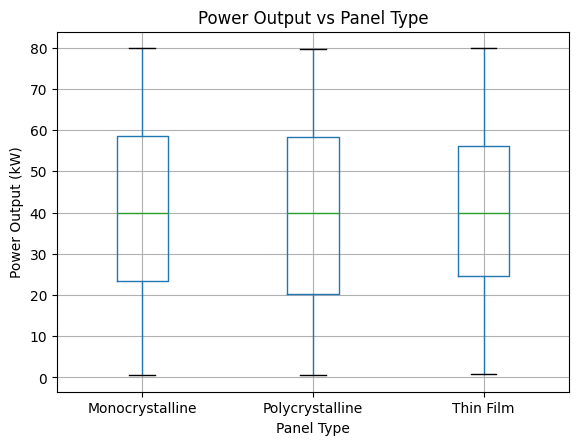

In [53]:
plt.figure()
df.boxplot(column='power_output_kw', by='panel_type')
plt.xlabel("Panel Type")
plt.ylabel("Power Output (kW)")
plt.title("Power Output vs Panel Type")
plt.suptitle("")
plt.show()


<Figure size 640x480 with 0 Axes>

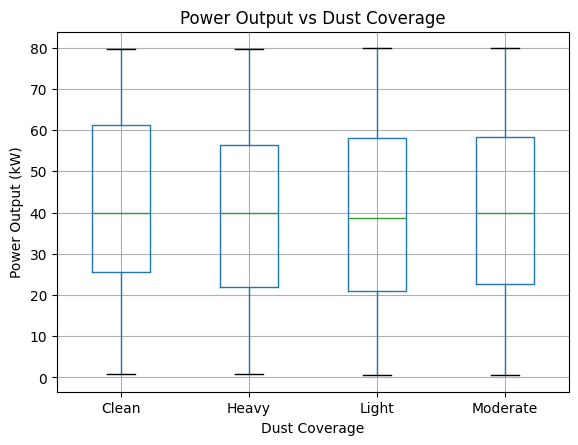

In [54]:
plt.figure()
df.boxplot(column='power_output_kw', by='dust_coverage')
plt.xlabel("Dust Coverage")
plt.ylabel("Power Output (kW)")
plt.title("Power Output vs Dust Coverage")
plt.suptitle("")
plt.show()


<Figure size 640x480 with 0 Axes>

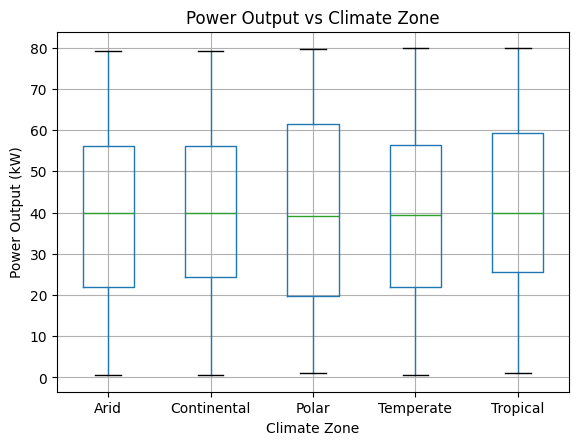

In [55]:
plt.figure()
df.boxplot(column='power_output_kw', by='climate_zone')
plt.xlabel("Climate Zone")
plt.ylabel("Power Output (kW)")
plt.title("Power Output vs Climate Zone")
plt.suptitle("")
plt.show()


<Figure size 640x480 with 0 Axes>

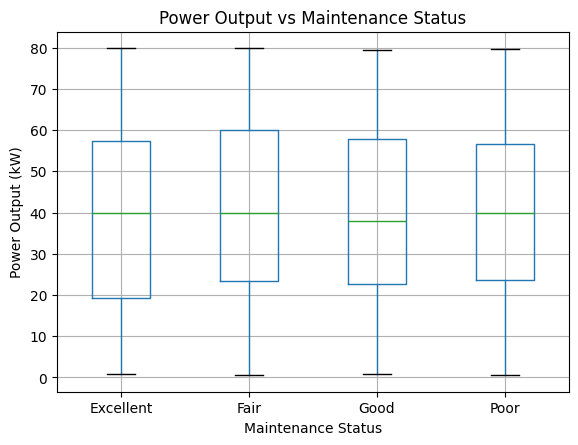

In [56]:
plt.figure()
df.boxplot(column='power_output_kw', by='maintenance_status')
plt.xlabel("Maintenance Status")
plt.ylabel("Power Output (kW)")
plt.title("Power Output vs Maintenance Status")
plt.suptitle("")
plt.show()


<Figure size 640x480 with 0 Axes>

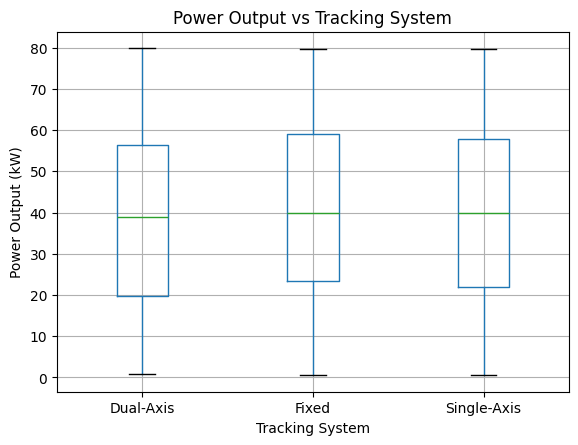

In [57]:
plt.figure()
df.boxplot(column='power_output_kw', by='tracking_system')
plt.xlabel("Tracking System")
plt.ylabel("Power Output (kW)")
plt.title("Power Output vs Tracking System")
plt.suptitle("")
plt.show()


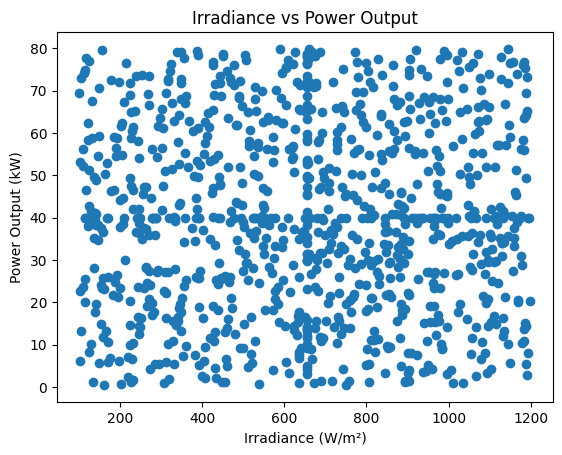

In [58]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['irradiance_wm2'], df['power_output_kw'])
plt.xlabel("Irradiance (W/m²)")
plt.ylabel("Power Output (kW)")
plt.title("Irradiance vs Power Output")
plt.show()


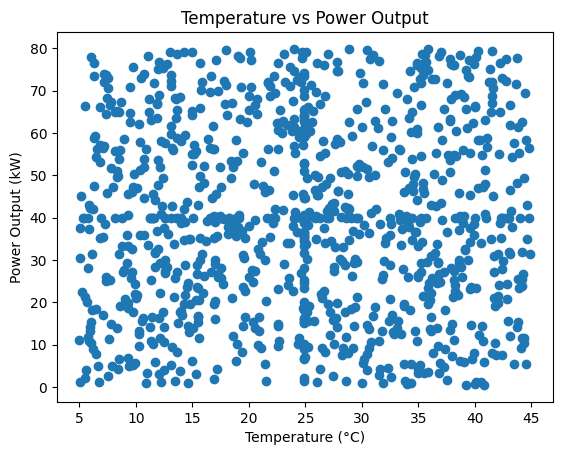

In [59]:
plt.figure()
plt.scatter(df['temperature_c'], df['power_output_kw'])
plt.xlabel("Temperature (°C)")
plt.ylabel("Power Output (kW)")
plt.title("Temperature vs Power Output")
plt.show()


In [60]:
#Encoding the categorical data
df = pd.get_dummies(df, drop_first=True)
df.head()


,irradiance_wm2,panel_angle_degrees,temperature_c,panel_efficiency_percent,array_size_kw,shading_percent,inverter_efficiency,power_output_kw,panel_type_Polycrystalline,panel_type_Thin Film,...,dust_coverage_Moderate,tracking_system_Fixed,tracking_system_Single-Axis,climate_zone_Continental,climate_zone_Polar,climate_zone_Temperate,climate_zone_Tropical,maintenance_status_Fair,maintenance_status_Good,maintenance_status_Poor
0,854.942691,34.939874,12.136416,19.908985,73.252112,4.452474,96.266765,29.220686,False,False,...,False,False,False,False,True,False,False,False,True,False
1,873.514217,58.963949,40.301998,21.918331,21.524243,3.320695,95.735455,58.413629,True,False,...,True,True,False,False,False,False,False,True,False,False
2,291.329020,19.630756,6.456214,16.079822,30.092401,18.615808,94.368534,54.449089,True,False,...,False,True,False,True,False,False,False,True,False,False
3,837.519833,47.294956,11.933868,15.000939,12.325641,27.325297,91.833368,53.714984,True,False,...,False,False,False,False,True,False,False,True,False,False
4,384.383089,37.248946,16.741221,18.960743,80.352410,29.864718,95.642530,44.604038,False,True,...,True,True,False,False,False,True,False,True,False,False


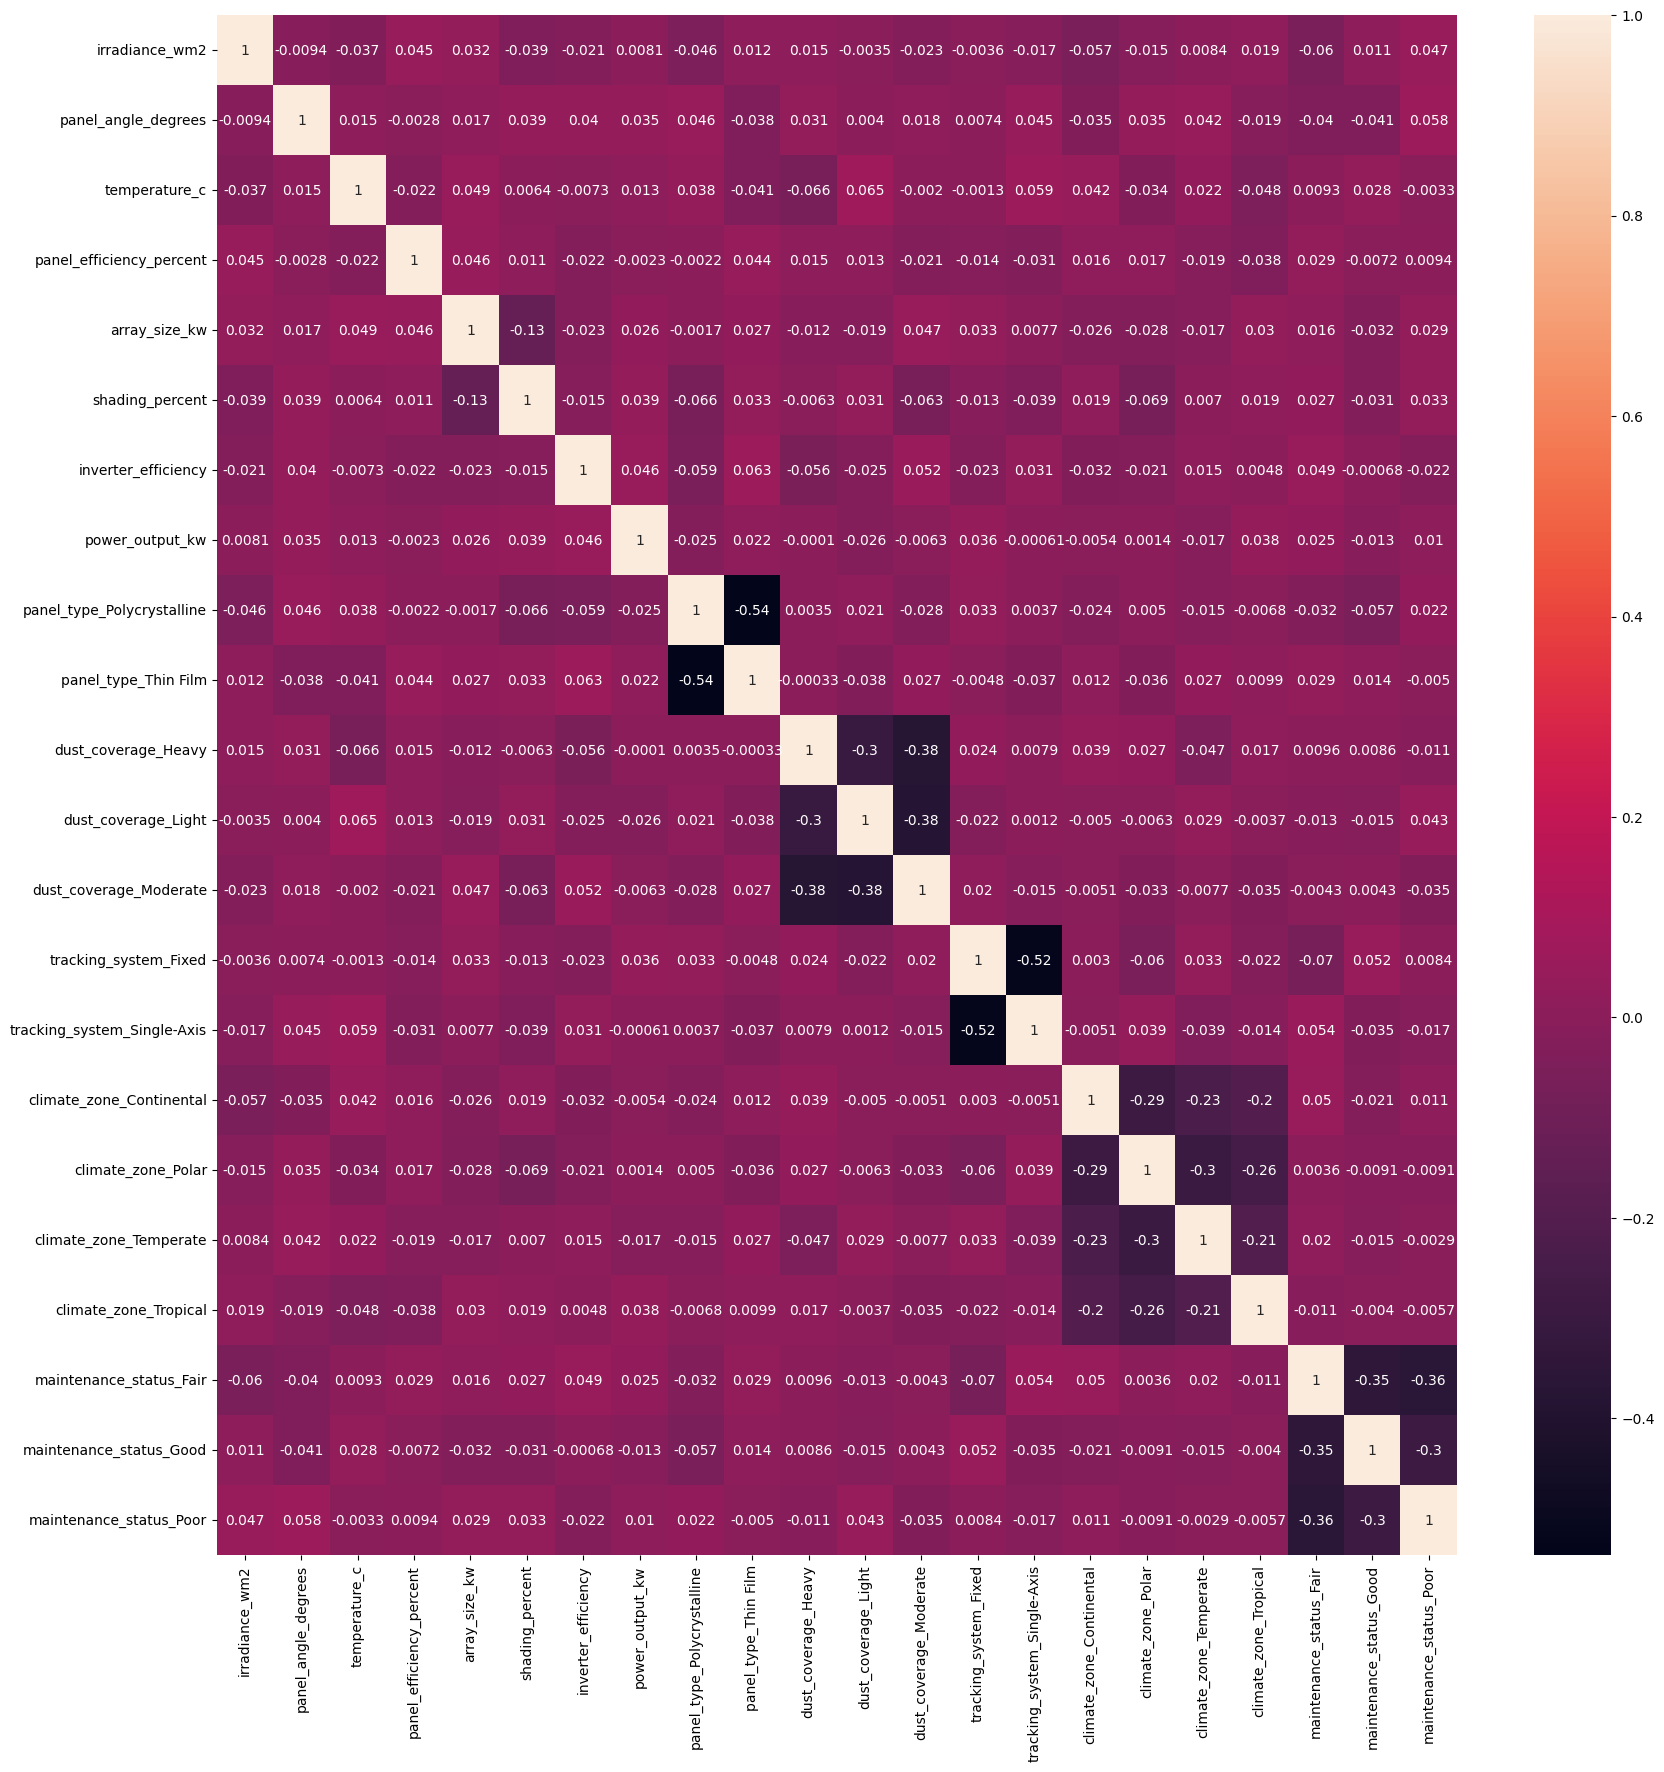

In [72]:
import seaborn as sns
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [62]:
df.dropna(subset=['power_output_kw'], inplace=True)
X = df.drop('power_output_kw', axis=1)
y = df['power_output_kw']

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [64]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [65]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)


R² Score: -0.02907267773567579


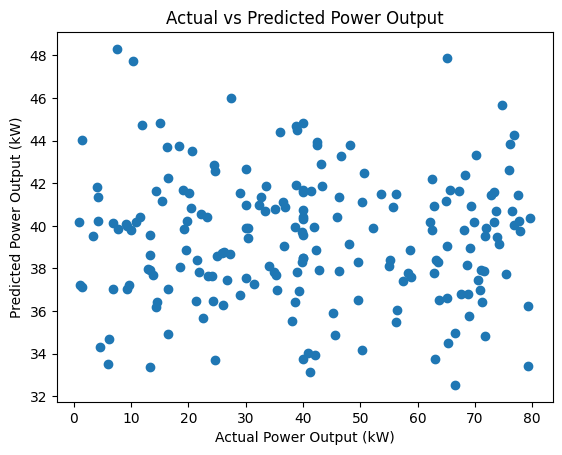

In [66]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Power Output (kW)")
plt.ylabel("Predicted Power Output (kW)")
plt.title("Actual vs Predicted Power Output")
plt.show()
